## House Prices: Understanding & Comparing Gradient Boosting & Encoding Techniques

**Goal:** Accurately forecast Ames house sales prices (`SalePrice`) using an XGBoost regression model, with deliberate domain-driven preprocessing and category encoding.

### The Strategy:
1. **Target Analysis:** Log-transform `SalePrice` with `np.log1p` to correct for high positive skew.
2. **Domain-Driven Missing Value Imputation:** Separate true data gaps from intentional `NA` codes meaning absence of amenities (`None` / `0`).
3. **Neighborhood-Specific Imputation:** Impute `LotFrontage` using neighborhood medians.
4. **Data Type Correction:** Convert `MSSubClass` from arbitrary numbers into categorical strings.
5. **Matched Encoding:** Apply custom **Ordinal Encoding** to quality ladders (`Ex > Gd > TA > Fa > Po > None`) and **One-Hot Encoding** to nominal features.
6. **Modeling & Validation:** Train and evaluate an XGBoost regressor using Root Mean Squared Error (RMSE) in log space, inspect feature importances, and produce final test predictions.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Data Ingestion & Initial Inspection

We load both `train.csv` (containing `SalePrice`) and `test.csv` (which lacks `SalePrice` and requires our predictions).


In [24]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Training dataset shape:   {train.shape}")
print(f"Test dataset shape:       {test.shape}")
train.head()


Training dataset shape:   (1460, 81)
Test dataset shape:       (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Look at the target

SalePrice is right-skewed  most houses are average-priced, a few are very expensive. We log-transform it with log1p before training so big errors on expensive houses don't dominate. We turn predictions back into dollars with expm1 at the end.


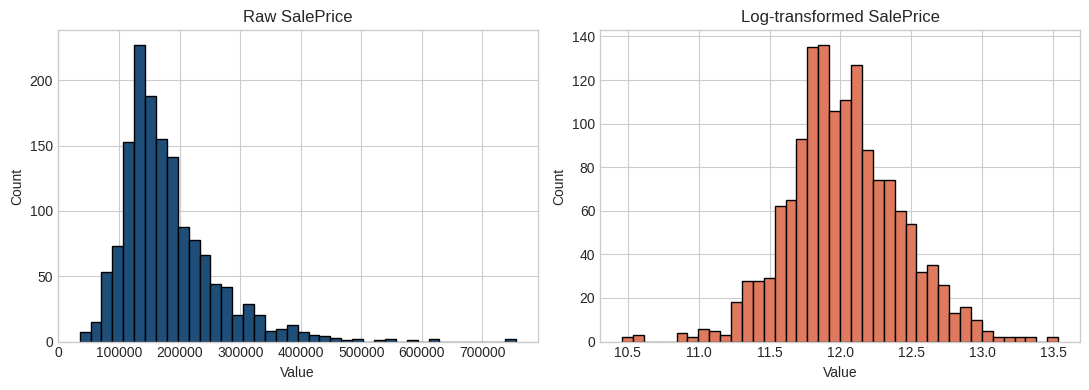

In [36]:
target = train_df[TARGET_COLUMN]
target_log = np.log1p(target)

datasets = [
    ('Raw SalePrice', target, '#1f4e79'),
    ('Log-transformed SalePrice', target_log, '#e07a5f'),
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

for ax, (label, data, color) in zip(axes, datasets):
    ax.hist(data, bins=40, color=color, edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 3. Missing values

Checking **data_description.txt**, many NA values here don't mean data is missing, they mean the house doesn't have that feature:
- PoolQC = NA means no pool
- GarageType = NA means no garage
- BsmtQual = NA means no basement

So we handle them in groups:
1. Categoricals where NA means none, fill with None
2. Numerics where NA means 0, such as garage area and basement area
3. LotFrontage, fill with the median of the same neighborhood
4. The few genuinely missing values, fill with the most common value (mode)


In [26]:
n_train = train.shape[0]
y = np.log1p(train['SalePrice'])
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)


none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')


zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)


all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda s: s.fillna(s.median())
)

mode_cols = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'Electrical', 'KitchenQual', 'Functional', 'SaleType'
]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f"Remaining unhandled missing values across all_data: {all_data.isnull().sum().sum()}")


Remaining unhandled missing values across all_data: 0


## 4. Correcting Numerical Encodings: `MSSubClass`

`MSSubClass` records building types using numbers (`20`, `60`, `120`, etc.). These are **discrete categorical codes**, not physical measurements. 

Leaving them as integers would lead linear models and tree-split algorithms to assume an artificial numerical order (e.g. that class 120 is double class 60). Converting them to string ensures they are properly handled as nominal categories.


In [27]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)


## 5. Ordinal encode the quality columns

Some columns use a quality rating from None up to Ex. Since there is a clear order, I map them to numbers from 0 to 5 instead of one-hot encoding them. That way the model knows Ex is better than Fa.


In [37]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    all_data[col] = all_data[col].map(quality_map)

all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['GarageFinish'] = all_data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})


## 6. One-Hot Encoding Nominal Features & Train/Test Partitioning

Features that lack natural hierarchy (e.g., `Neighborhood`, `MSZoning`, `SaleType`, `MSSubClass`) are converted into binary dummy variables via `pd.get_dummies(drop_first=True)`. 

Because this is performed on the unified `all_data`, training and test matrices share identical column schemas.


In [38]:
all_data = pd.get_dummies(all_data, drop_first=True)

X = all_data.iloc[:n_train, :].drop('Id', axis=1)
X_test = all_data.iloc[n_train:, :].drop('Id', axis=1)

print(f"X (training features) shape: {X.shape}")
print(f"X_test (test features) shape: {X_test.shape}")


X (training features) shape: (1460, 228)
X_test (test features) shape: (1459, 228)


## 7. Model Validation Strategy

We set aside 20% of the labeled dataset for validation to evaluate out-of-sample generalization performance prior to scoring test data.


In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")


Training set:   1168 samples
Validation set: 292 samples


## 8. XGBoost Model Training & Out-of-Fold Evaluation

We use an XGBoost regressor with controlled tree depth (`max_depth=3`) and conservative learning rate (`learning_rate=0.03`) along with feature/row subsampling to mitigate overfitting on sparse one-hot columns.


In [40]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

xgb.fit(X_train, y_train)

val_preds = xgb.predict(X_val)
val_rmse = root_mean_squared_error(y_val, val_preds)
print(f"Validation RMSE (Log Scale): {val_rmse:.4f}")


Validation RMSE (Log Scale): 0.1306


## 9. Feature Importance Analysis

Examining the features XGBoost relied on most reveals whether the model learned intuitive housing drivers (e.g. overall quality, square footage, basement finishing).


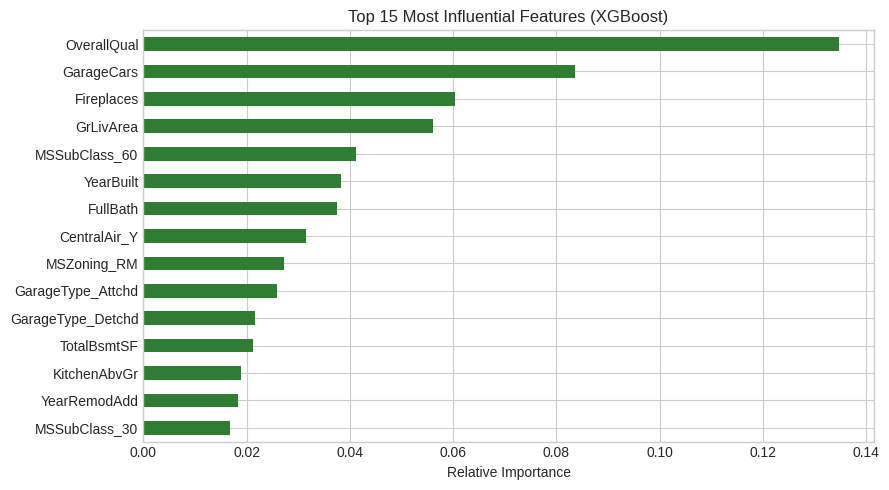

In [41]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind='barh', color='#2e7d32')
plt.title('Top 15 Most Influential Features (XGBoost)', fontsize=12)
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()


## 10. Full-Data Retraining & Submission Generation

To maximize predictive power on Kaggle test instances, we retrain the model across 100% of the available training data (`X, y`) and revert predictions from log-space back into dollar values using `np.expm1`.


In [42]:
xgb_final = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)
xgb_final.fit(X, y)

final_preds = np.expm1(xgb_final.predict(X_test))

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission file successfully saved as 'submission.csv'!")
submission.head()


Submission file successfully saved as 'submission.csv'!


,Id,SalePrice
0,1461,122807.78125
1,1462,155566.18750
2,1463,188344.50000
3,1464,188679.59375
4,1465,189498.12500
